# Obiettivo del Progetto

L'obiettivo principale di questa analisi è trasformare i dati grezzi transazionali e logistici dell'e-commerce dell'azienda OLIS in insight strategici azionabili. 
Il mio lavoro punta a rispondere alle seguenti domande chiave:

1. Quali sono i reali driver di fatturato? Come reagiscono i volumi di vendita alle variazioni di prezzo nelle diverse categorie di prodotto?

2. In che misura i tempi di consegna influenzano direttamente la soddisfazione del cliente e, di conseguenza, la probabilità di riacquisto?

3. In quali aree geografiche le inefficienze nella fase di consegna stanno compromettendo maggiormente l'esperienza utente?

Il risultato finale di questo progetto è un piano d'azione data-driven volto a ottimizzare i ricavi, ricalibrare i prezzi, mitigare i rischi logistici e, in definitiva, incrementare la customer satisfaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Caricamento dati e panoramica
Carichiamo il nostro dataset delle vendite dell'ecommerce e otteniamo una prima comprensione della sua struttura e del suo contenuto.

In [2]:
customers = pd.read_csv('Dataset/olist_customers_dataset.csv')
items     = pd.read_csv('Dataset/olist_order_items_dataset.csv')
products  = pd.read_csv('Dataset/olist_products_dataset.csv')
reviews   = pd.read_csv('Dataset/olist_order_reviews_dataset.csv')
orders    = pd.read_csv('Dataset/olist_orders_dataset.csv')


In [3]:
customers.head()   

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [6]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# Statistiche Dataset

In [8]:

dfs = {
    'Orders': orders,
    'Customers': customers,
    'Items': items,
    'Products': products,
    'Reviews': reviews
}
def explore_dataframe(name, df):
    print(f"\n{'='*40}")
    print(f"REPORT: {name}")
    print(f"{'='*40}")

    # DIMENSIONI
    print(f"1. Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne")

    # VALORI MANCANTI
    missing_count = df.isnull().sum()
    missing_only = missing_count[missing_count > 0]
    if not missing_only.empty:
        print("\n2. Colonne con valori mancanti:")
        print(missing_only)
    else:
        print("\n2. Nessun valore mancante.")

    # DUPLICATI PER COLONNA
    print("\n3. Duplicati per colonna:")

    duplicate_counts = df.apply(lambda x: x.duplicated().sum())
    print(duplicate_counts)
    
    # TIPI DI DATI
    print("\n4. Tipi di dati:")
    print(df.dtypes)

    #OUTLIERS
    print("\n5. Analisi Outlier (Metodo IQR):")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        print(f"{'Colonna':<30} | {'Outliers':<10} | {'Min':<10} | {'Max':<10}")
        print("-" * 70)
        
        for col in numeric_cols:
            Q1 = df[col].quantile(0.05)
            Q3 = df[col].quantile(0.95)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            
            print(f"{col:<30} | {outliers:<10} | {df[col].min():<10.2f} | {df[col].max():<10.2f}")
    else:
        print("   Nessuna colonna numerica trovata.")
    

for name, df in dfs.items():
    explore_dataframe(name, df)


REPORT: Orders
1. Dimensioni: 99441 righe, 8 colonne

2. Colonne con valori mancanti:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

3. Duplicati per colonna:
order_id                             0
customer_id                          0
order_status                     99433
order_purchase_timestamp           566
order_approved_at                 8707
order_delivered_carrier_date     18422
order_delivered_customer_date     3776
order_estimated_delivery_date    98982
dtype: int64

4. Tipi di dati:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

5. Analisi Outlier (Metodo IQR):
   Nessuna colonna numerica trovata.

REPORT: Cu

1. Struttura dei dati e relazioni

Tabella Centrale: orders collega tutte le altre tabelle tramite order_id.

Relazioni Uno-a-Molti: Riscontrate in items (più prodotti per singolo ordine) e payments (pagamenti frazionati/multipli).

Logica ID Cliente: customer_id è specifico per la transazione; customer_unique_id traccia l'utente reale. 

2. Qualità dei dati

Formato Date: Tutte le colonne temporali in orders sono attualmente stringhe (object) e richiedono la conversione in datetime.

Valori Mancanti:

Orders - i valori null in order_delivered_customer_date indicano ordini cancellati o ancora in transito.

Reviews - alta percentuale di valori mancanti in review_comment_message (~58%) e review_comment_title (~88%). Questo è un comportamento atteso (gli utenti lasciano valutazioni a stelle senza feedback scritto).

3. Order status:

La stragrande maggioranza degli ordini risulta "delivered" (consegnata), ma esistono stati come "canceled" (cancellato) e "unavailable" (non disponibile) che dovrebbero essere filtrati per l'analisi delle vendite.



4. Outliers 

Gli outlier relativi a prezzo e peso sono stati analizzati e confermati come transazioni legittime piuttosto che errori di inserimento dati. Nello specifico, i valori anomali nel prezzo rappresentano il segmento Luxury (ad esempio orologi di fascia alta), mentre gli outlier relativi al peso e al costo di spedizione corrispondono a merci pesanti o ingombranti.

# Data Cleaning

In [9]:
#Correzione delle date
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])


In [10]:
# Controllo di integrità: rimuovo le righe in cui tutte le colonne sono identiche.
orders.drop_duplicates(inplace=True)
items.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
reviews.drop_duplicates(inplace=True)

## Considerazioni su duplicati della key di merge

In [11]:
# count order_id occurrences and show those >1
dup_counts = items['order_id'].value_counts()
dup_orders = dup_counts[dup_counts > 1]
print(f"{len(dup_orders)} duplicated order_id(s), examples:")
display(dup_orders.head(20))


9803 duplicated order_id(s), examples:


order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
2c2a19b5703863c908512d135aa6accc    12
c05d6a79e55da72ca780ce90364abed9    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
637617b3ffe9e2f7a2411243829226d0    12
af822dacd6f5cff7376413c03a388bb7    12
7f2c22c54cbae55091a09a9653fd2b8a    11
71dab1155600756af6de79de92e712e3    11
6c355e2913545fa6f72c40cbca57729e    11
5a3b1c29a49756e75f1ef513383c0c12    11
a483ffe0ce133740ab12ebcba8a3ccf9    10
9aec4e1ae90b23c7bf2d2b3bfafbd943    10
ca3625898fbd48669d50701aba51cd5f    10
Name: count, dtype: int64

In [12]:
order_id = '8272b63d03f5f79c56e9e4120aec44ef'

# Rows in the items table
print("Items rows count:", items[items['order_id'] == order_id].shape[0])
display(items[items['order_id'] == order_id].sort_values('order_item_id'))



Items rows count: 21


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57305,8272b63d03f5f79c56e9e4120aec44ef,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89
57306,8272b63d03f5f79c56e9e4120aec44ef,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.2,7.89


In [13]:
# Rows in the order table
print("order rows count:", orders[orders['order_id'] == '8272b63d03f5f79c56e9e4120aec44ef'].shape[0])
display(orders[orders['order_id'] == '8272b63d03f5f79c56e9e4120aec44ef'])

order rows count: 1


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
88849,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28


A seguito di questo check mi accorgo che per un singolo ordine posso avere più oggetti e che order_item_id è semplicemente il conteggio degli oggetti nell'ordine, il prezzo è legato al singolo item e non all'ordine. 

Per calcolare l'incasso in modo corretto, parto dalla tabella `items` (che contiene il prezzo esatto di ogni prodotto di ordine). Poi, tramite un left join, unisco la tabella `orders` per ottenere i dettagli dell'ordine (come la data di acquisto) e infine la tabella `products` per le categorie di prodotto.

## Merge

In [14]:
print(orders.shape)
print(items.shape)
print(products.shape)

(99441, 8)
(112650, 7)
(32951, 9)


Mi aspetto un df con shape uguale a quella di items

In [15]:
df = items.merge(orders, on='order_id', how='left')

In [16]:
df.shape

(112650, 14)

In [17]:
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')

In [18]:
df.shape

(112650, 26)

## Filtering

In [19]:
# filtro il dataframe per avere solo gli ordini consegnati
df_delivered = df[df['order_status'].str.lower() == 'delivered'].copy()
display(df_delivered.head())
print(df_delivered.shape)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,598.0,4.0,650.0,28.0,9.0,14.0,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,239.0,2.0,30000.0,50.0,30.0,40.0,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,695.0,2.0,3050.0,33.0,13.0,33.0,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,480.0,1.0,200.0,16.0,10.0,15.0,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,409.0,1.0,3750.0,35.0,40.0,30.0,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


(110197, 26)


prendo solo quelli con stato 'delivered' cosi posso fare un'analisi degli ordini andati a buon fine

ora voglio vedere quale sono le categorie prodotto con più incassi

In [20]:
grouped = (df
           .groupby('product_category_name')['price']
           .sum()
           .sort_values(ascending=False)
           .reset_index(name='total_price'))

total_sum = grouped['total_price'].sum()
grouped['pct_of_total'] = (grouped['total_price'] / total_sum * 100).round(2)

display(grouped.head(50))

,product_category_name,total_price,pct_of_total
0,beleza_saude,1258681.34,9.38
1,relogios_presentes,1205005.68,8.98
2,cama_mesa_banho,1036988.68,7.73
3,esporte_lazer,988048.97,7.37
4,informatica_acessorios,911954.32,6.80
5,moveis_decoracao,729762.49,5.44
6,cool_stuff,635290.85,4.74
7,utilidades_domesticas,632248.66,4.71
8,automotivo,592720.11,4.42
9,ferramentas_jardim,485256.46,3.62


ora continuo la mia analisi solo sulle prime 5 categorie prodotto che rappresentano circa 40% degli incassi totali

In [21]:
# filtro il dataframe per mantenere solo le prime 5 categorie per incasso
categories = ['beleza_saude','relogios_presentes','cama_mesa_banho','esporte_lazer','informatica_acessorios']
df_filtered = df[df['product_category_name'].isin(categories)].copy()
print(df_filtered.shape)
df_filtered.head()

(43244, 26)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,...,493.0,1.0,2000.0,30.0,12.0,16.0,639d23421f5517f69d0c3d6e6564cf0e,11075,santos,SP
10,00061f2a7bc09da83e415a52dc8a4af1,1,d63c1011f49d98b976c352955b1c4bea,cc419e0650a3c5ba77189a1882b7556a,2018-03-29 22:28:09,59.99,8.88,c6fc061d86fab1e2b2eac259bac71a49,delivered,2018-03-24 22:16:10,...,614.0,1.0,950.0,35.0,25.0,20.0,107e6259485efac66428a56f10801f4f,13419,piracicaba,SP
12,0006ec9db01a64e59a68b2c340bf65a7,1,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,2018-07-26 17:24:20,74.00,23.32,5d178120c29c61748ea95bac23cb8f25,delivered,2018-07-24 17:04:17,...,245.0,1.0,1383.0,50.0,10.0,40.0,7ed0ea20347f67fe61d1c99fdf8556ae,21810,rio de janeiro,RJ
15,0009792311464db532ff765bf7b182ae,1,8cab8abac59158715e0d70a36c807415,530ec6109d11eaaf87999465c6afee01,2018-08-17 12:15:10,99.90,27.65,2a30c97668e81df7c17a8b14447aeeba,delivered,2018-08-14 20:43:09,...,1392.0,4.0,1050.0,40.0,20.0,30.0,4987996ddcd0ddb20740fdce7c2bfbb1,37137,alfenas,MG
18,000c3e6612759851cc3cbb4b83257986,1,b50c950aba0dcead2c48032a690ce817,218d46b86c1881d022bce9c68a7d4b15,2017-08-21 03:33:13,99.00,13.71,3773bcf1a6fbd29233ea1c1b573c4f22,delivered,2017-08-12 10:08:57,...,2584.0,1.0,1800.0,16.0,16.0,16.0,f5f088001070650f9e9a8cd773621f35,13208,jundiai,SP


In [22]:
# estraggo l'anno e il mese dalla data di acquisto
df_filtered['order_year'] = df_filtered['order_purchase_timestamp'].dt.year
df_filtered['month_year'] = df_filtered['order_purchase_timestamp'].dt.to_period('M')
df_filtered.head()
df_filtered


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_year,month_year
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,...,2000.0,30.0,12.0,16.0,639d23421f5517f69d0c3d6e6564cf0e,11075,santos,SP,2018,2018-03
10,00061f2a7bc09da83e415a52dc8a4af1,1,d63c1011f49d98b976c352955b1c4bea,cc419e0650a3c5ba77189a1882b7556a,2018-03-29 22:28:09,59.99,8.88,c6fc061d86fab1e2b2eac259bac71a49,delivered,2018-03-24 22:16:10,...,950.0,35.0,25.0,20.0,107e6259485efac66428a56f10801f4f,13419,piracicaba,SP,2018,2018-03
12,0006ec9db01a64e59a68b2c340bf65a7,1,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,2018-07-26 17:24:20,74.00,23.32,5d178120c29c61748ea95bac23cb8f25,delivered,2018-07-24 17:04:17,...,1383.0,50.0,10.0,40.0,7ed0ea20347f67fe61d1c99fdf8556ae,21810,rio de janeiro,RJ,2018,2018-07
15,0009792311464db532ff765bf7b182ae,1,8cab8abac59158715e0d70a36c807415,530ec6109d11eaaf87999465c6afee01,2018-08-17 12:15:10,99.90,27.65,2a30c97668e81df7c17a8b14447aeeba,delivered,2018-08-14 20:43:09,...,1050.0,40.0,20.0,30.0,4987996ddcd0ddb20740fdce7c2bfbb1,37137,alfenas,MG,2018,2018-08
18,000c3e6612759851cc3cbb4b83257986,1,b50c950aba0dcead2c48032a690ce817,218d46b86c1881d022bce9c68a7d4b15,2017-08-21 03:33:13,99.00,13.71,3773bcf1a6fbd29233ea1c1b573c4f22,delivered,2017-08-12 10:08:57,...,1800.0,16.0,16.0,16.0,f5f088001070650f9e9a8cd773621f35,13208,jundiai,SP,2017,2017-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112643,fffb9224b6fc7c43ebb0904318b10b5f,4,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,4d3abb73ceb86353aeadbe698aa9d5cb,delivered,2017-10-27 16:51:00,...,350.0,16.0,14.0,11.0,f736308cd9952b33b90b9fe94da9c8f5,56912,serra talhada,PE,2017,2017-10
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,8950.0,45.0,26.0,38.0,0da9fe112eae0c74d3ba1fe16de0988b,81690,curitiba,PR,2018,2018-07
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,967.0,21.0,24.0,19.0,cd79b407828f02fdbba457111c38e4c4,4039,sao paulo,SP,2017,2017-10
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,100.0,20.0,20.0,20.0,eb803377c9315b564bdedad672039306,13289,vinhedo,SP,2017,2017-08


In [23]:
# raggruppo per anno e categoria, calcolando incasso totale e numero di articoli venduti
result = (df_filtered
          .groupby(['order_year', 'product_category_name'])
          .agg(total_price=('price', 'sum'),
               items_count=('order_item_id', 'count'))
          .reset_index())

# calcolo delta assoluto rispetto all'anno precedente per categoria
result = result.sort_values(['product_category_name', 'order_year'])
result['delta_total_price'] = result.groupby('product_category_name')['total_price'].diff().abs()
result['delta_items_count'] = result.groupby('product_category_name')['items_count'].diff().abs()


result = result.sort_values(['order_year', 'total_price'], ascending=[True, False]).reset_index(drop=True)
display(result)

,order_year,product_category_name,total_price,items_count,delta_total_price,delta_items_count
0,2016,beleza_saude,4687.48,51,NaN,NaN
1,2016,relogios_presentes,3360.24,5,NaN,NaN
2,2016,esporte_lazer,3333.64,19,NaN,NaN
3,2016,informatica_acessorios,1399.32,21,NaN,NaN
4,2016,cama_mesa_banho,478.99,8,NaN,NaN
5,2017,cama_mesa_banho,498440.43,5223,497961.44,5215.0
6,2017,relogios_presentes,492794.50,2283,489434.26,2278.0
7,2017,beleza_saude,481755.71,3668,477068.23,3617.0
8,2017,esporte_lazer,452148.84,4095,448815.20,4076.0
9,2017,informatica_acessorios,405078.69,3098,403679.37,3077.0


In [24]:
# per quali mesi del 2016 sono presenti dati in df_top5
df_2016 = df_filtered[df_filtered['order_year'] == 2016]

if df_2016.empty:
    print("No records for 2016")
else:
    print("2016 min:", df_2016['order_purchase_timestamp'].min())
    print("2016 max:", df_2016['order_purchase_timestamp'].max())

2016 min: 2016-09-15 12:16:38
2016 max: 2016-10-10 18:05:54


In [25]:
# per quali mesi del 2018 sono presenti dati in df_top5
df_2018 = df_filtered[df_filtered['order_year'] == 2018]

if df_2018.empty:
    print("No records for 2018")
else:
    print("2018 min:", df_2018['order_purchase_timestamp'].min())
    print("2018 max:", df_2018['order_purchase_timestamp'].max())

2018 min: 2018-01-01 08:45:04
2018 max: 2018-08-29 15:00:37


L'obiettivo era quello di vedere la crescita delle vendite nelle top 5 categorie prodotto per incasso nel arco di 3 anni. Mi accorgo però che nel primo anno abbiamo solo 2 mesi di records, concentro quindi analisi solo al 2017 e 2018. Prima mostro l'andamento per mese delle vendite.

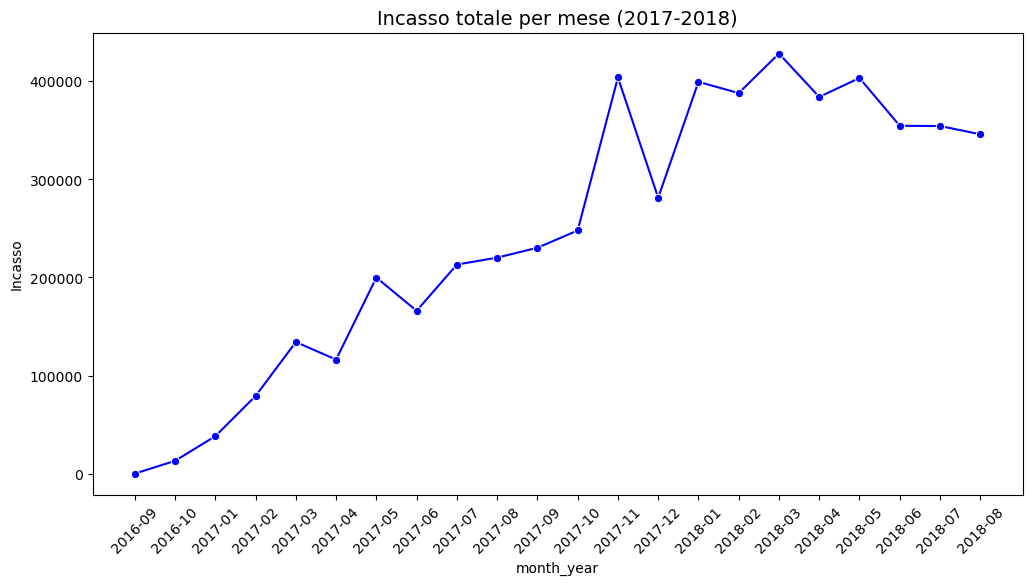

In [26]:
# Trend mensile degli incassi
monthly_revenue = df_filtered.groupby('month_year')['price'].sum().reset_index()
monthly_revenue['month_year'] = monthly_revenue['month_year'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue, x='month_year', y='price', marker='o', color='b')
plt.title('Incasso totale per mese (2017-2018)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Incasso')
plt.show()

# Sales and Strategic Analysis

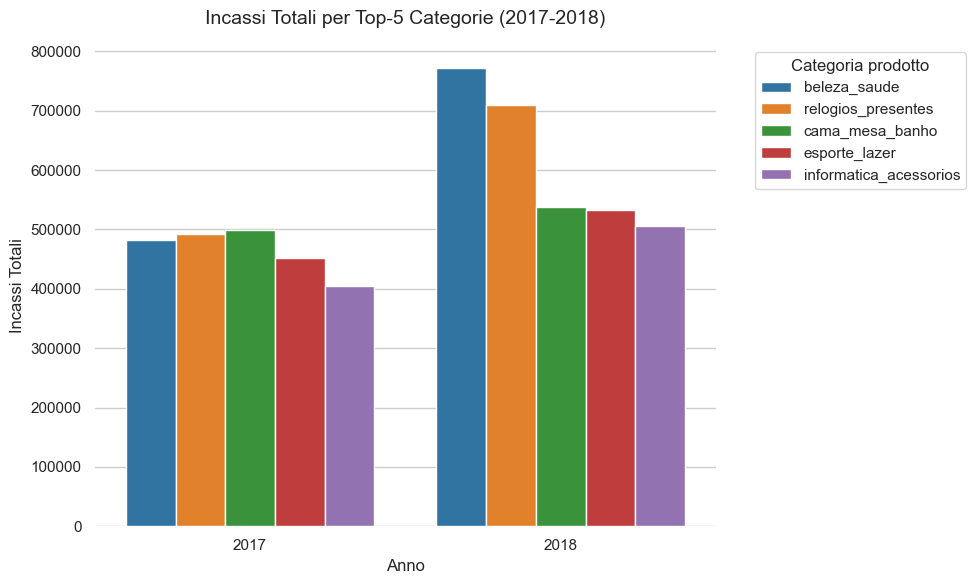

In [27]:
# preparo i dati per il grafico a barre
df_revenue = (
    df_filtered[
        (df_filtered['order_year'] != 2016) & 
        (df_filtered['product_category_name'].isin(categories))
    ]
    .groupby(['order_year', 'product_category_name'])
    .agg(total_price=('price', 'sum'))
    .reset_index()
)

# setto lo stile di Seaborn e la dimensione della figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# setto la tavolozza dei colori a 'tab10' per mantenere i colori originali
ax = sns.barplot(
    data=df_revenue, 
    x='order_year', 
    y='total_price', 
    hue='product_category_name',
    hue_order=categories, 
    palette='tab10'
)

ax.set_title('Incassi Totali per Top-5 Categorie (2017-2018)', fontsize=14, pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Incassi Totali', fontsize=12)


plt.legend(title='Categoria prodotto', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(left=True, bottom=True) 

plt.tight_layout()
plt.show()

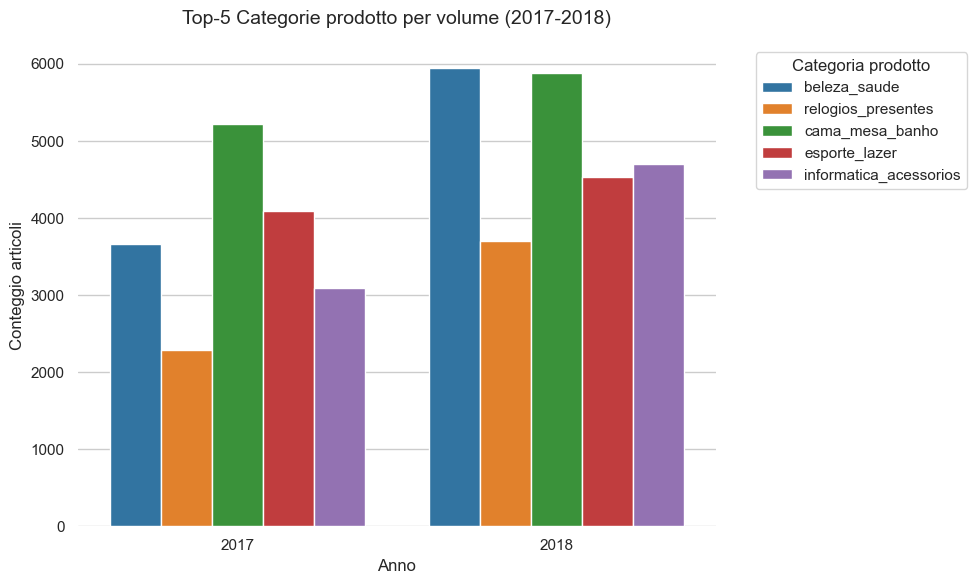

In [28]:
# preparo i dati per il grafico a barre
df_items_count = (
    df_filtered[
        (df_filtered['order_year'] != 2016) & 
        (df_filtered['product_category_name'].isin(categories))
    ]
    .groupby(['order_year', 'product_category_name'])
    .agg(items_count=('order_item_id', 'count'))
    .reset_index()
)

# setto lo stile di Seaborn e la dimensione della figura
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# cerco di mantenere i colori originali mappando le categorie alle stesse tonalità usate nel grafico precedente
try:
    prev_ax = fig.axes[0]
    prev_cols = list(pivot.columns) 
    colors_list = [c.patches[0].get_facecolor() for c in prev_ax.containers]
    color_map = dict(zip(prev_cols, colors_list))
    
    # creo una palette per il nuovo grafico basata sui colori mappati alle categorie
    palette = {cat: color_map.get(cat) for cat in categories}
    
    # controllo di fallback se qualche colore non è stato mappato correttamente
    if any(c is None for c in palette.values()):
        palette = sns.color_palette("tab10", len(categories))
except Exception:
    palette = sns.color_palette("tab10", len(categories))

ax = sns.barplot(
    data=df_items_count, 
    x='order_year', 
    y='items_count', 
    hue='product_category_name',
    hue_order=categories, 
    palette=palette
)

ax.set_title('Top-5 Categorie prodotto per volume (2017-2018)', fontsize=14, pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Conteggio articoli', fontsize=12)

plt.legend(title='Categoria prodotto', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(left=True, bottom=True) 

plt.tight_layout()
plt.show()

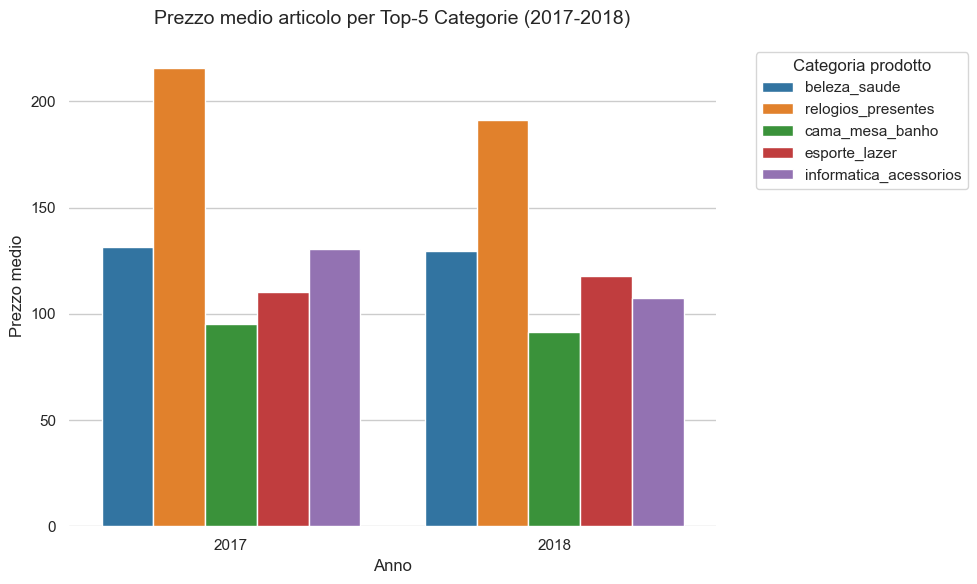

In [29]:
# preparo i dati per il grafico a barre
df_avg_price = (
    df_filtered[
        (df_filtered['order_year'].isin([2017, 2018])) & 
        (df_filtered['product_category_name'].isin(categories))
    ]
    .groupby(['order_year', 'product_category_name'])
    .agg(avg_price=('price', 'mean'))
    .reset_index()
)

# setto lo stile di Seaborn e la dimensione della figura
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 6))

# cerco di mantenere i colori originali mappando le categorie alle stesse tonalità usate nel grafico precedente
try:
    palette = {cat: color_map[cat] for cat in categories if cat in color_map}
except NameError:
    palette = sns.color_palette("tab10", len(categories))

ax = sns.barplot(
    data=df_avg_price, 
    x='order_year', 
    y='avg_price', 
    hue='product_category_name',
    hue_order=categories, 
    palette=palette
)

ax.set_title('Prezzo medio articolo per Top-5 Categorie (2017-2018)', fontsize=14, pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Prezzo medio', fontsize=12)

plt.legend(title='Categoria prodotto', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.show()

L'analisi congiunta di Incassi, Volumi e Prezzo Medio rivela i veri drivers del OLIS e-commerce tra il 2017 e il 2018. Pur essendoci stato un aumento generale del fatturato nella Top 5, ogni categoria è stata guidata da dinamiche di prezzo e livelli di elasticità completamente differenti.

Beleza & Saude (Salute e Bellezza) -  questa categoria ha registrato le performance migliori, raggiungendo il primo posto sia per i incassi totali (~780k) sia per il volume di articoli (~6.000 unità) nel 2018. È fondamentale notare che questa crescita esplosiva si è verificata mentre il prezzo medio dell'articolo è rimasto perfettamente stabile a circa 130. Ciò indica una domanda altamente inelastica; l'interesse dei consumatori sta guidando la crescita in modo del tutto organico, senza alcuna necessità di sconti promozionali.

Relogios & Presentes (Orologi e Regali) - qui il prezzo medio è stato ridotto da ~215 nel 2017 a ~190 nel 2018. Questo strategico calo di prezzo ha innescato una massiccia impennata dei volumi (da ~2.300 a ~3.700 articoli), che ha portato a un picco di ~710k nei incassi totali. Questo potrebbe essere positivo in caso che gli margini sul prodotto siano alti(non sono disponibile in dataset i vari costi).

Esporte & Lazer (Sport e Tempo Libero) - questa è l'unica tra le categorie principali in cui il prezzo medio dell'articolo è stato aumentato, passando da ~110 a ~120. Nonostante questo rincaro, il volume è comunque cresciuto, trainando una solida crescita dei incassi. Questo suggerisce una forte fedeltà al marchio o un alto valore percepito, indicando che l'azienda può aumentare i profitti.

Cama, Mesa, Banho (Letto, Tavola, Bagno) - un classico driver di volume. Mantiene vendite unitarie elevate (~5.900 nel 2018) ma registra il prezzo medio più basso della top 5 (in leggero calo da ~95 a ~90). La crescita dei incassi è stata moderata. Questa categoria richiede una rigorosa ottimizzazione logistica per garantire che i costi di spedizione non vadano a erodere i suoi margini già sottili.

Informatica Acessorios (Accessori IT) - in questo caso l'azienda ha tentato una strategia di sconti, abbassando bruscamente il prezzo medio da ~130 a ~105. Sebbene questo abbia effettivamente aumentato i volumi (da ~3.100 a ~4.700), ha prodotto la crescita dei incassi più debole tra le prime 5, lasciando la categoria all'ultimo posto per incassi totali. Inseguire i volumi attraverso gli sconti in questa categoria non rappresenta più una strategia di business efficiente.

In [30]:
df_filtered['order_year'].value_counts()

order_year
2018    24773
2017    18367
2016      104
Name: count, dtype: int64

In [31]:
df_filtered.shape

(43244, 28)

In [32]:
df_filtered = df_filtered[df_filtered['order_year'] != 2016]
df_filtered['order_year'].value_counts()

order_year
2018    24773
2017    18367
Name: count, dtype: int64

Qui sopra ho escluso l'anno 2016 dal df_filtered

In [33]:
dup_num = df_filtered['order_id'].value_counts()
dup_ord = dup_num[dup_num > 1]
print(f"{len(dup_ord)} duplicated order_id(s), examples:")
display(dup_ord.head(20))

3659 duplicated order_id(s), examples:


order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
3a213fcdfe7d98be74ea0dc05a8b31ae    12
5a3b1c29a49756e75f1ef513383c0c12    11
f80549a97eb203e1566e026ab66f045b    10
a483ffe0ce133740ab12ebcba8a3ccf9    10
04993613aee4046caf92ea17b316dcfb     8
4affd1928d3900a415e9886a179d5124     8
30bdf3d824d824610a49887486debcaf     8
612d140e314dab491efb33ec8219c2ee     8
df13cbaf3230c62a4b582317936e8a39     7
1c11d0f4353b31ac3417fbfa5f0f2a8a     7
8dd554aaa8e7d61ddde56ba4189c780f     7
2c3cc72ee484cfd2c93077c0dcb18c06     6
d1537836c453f9672f80c422d1af8cab     6
3cc744d9a46682c354778726d30e384f     6
5e71f5832e566171d43c90da65f506c4     6
2793a15df4b2130bcdbe0f125eee15ea     6
3caf6c286c8cde37ea9c0fb2da0e3169     6
35edfe0ed82ffa12bb88c0395209e513     6
Name: count, dtype: int64

In [34]:
dup_num = reviews['order_id'].value_counts()
dup_ord = dup_num[dup_num > 1]
print(f"{len(dup_ord)} duplicated order_id(s), examples:")
display(dup_ord.head(20))

547 duplicated order_id(s), examples:


order_id
c88b1d1b157a9999ce368f218a407141    3
8e17072ec97ce29f0e1f111e598b0c85    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
5cb890a68b91b6158d69257e4e2bc359    2
2143393cca994a4b8235bc1d67ded772    2
25320e12b3d6e8f54f17389037588bba    2
0176a6846bcb3b0d3aa3116a9a768597    2
d9e44c3fd2ce16086619f299e92e12d8    2
21cb4961399b846b168d0358100f473b    2
6b99ff92735c747557e84a5f5cd7a560    2
1a69d5fdff0003d4571dffa1a9a10967    2
28a32ec11abbac5c27adfa4d8cbc351a    2
a979479c1af57af858b45dfd2d67ee04    2
acd76a8508680cbb5d4c04707be03f87    2
75d5d3d16567a27eefc5752aeb063072    2
cbf088f9ac169d9c7eddcaa9c5e465fe    2
14d35062b86c2e1f69376af68e9e2a1e    2
61b2314bd576f3d792e46e1d56e51ee6    2
8f5fac100b291e3c7c7c34ca50001b5a    2
Name: count, dtype: int64

In [35]:
order_id = 'c88b1d1b157a9999ce368f218a407141'

# righe nella tabella reviews
print("Reviews count:", reviews[reviews['order_id'] == order_id].shape[0])
display(reviews[reviews['order_id'] == order_id])

Reviews count: 3


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1985,ffb8cff872a625632ac983eb1f88843c,c88b1d1b157a9999ce368f218a407141,3,NaN,NaN,2017-07-22,2017-07-26 13:41:07
82525,202b5f44d09cd3cfc0d6bd12f01b044c,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-22,2017-07-26 13:40:22
89360,fb96ea2ef8cce1c888f4d45c8e22b793,c88b1d1b157a9999ce368f218a407141,5,NaN,NaN,2017-07-21,2017-07-26 13:45:15


Voglio fare un merge tra la tabella 'df_filtered' analizzata in precedenza e la tabella 'review', mi accorgo che ci sono duplicati per la chiave di merge per entrambe le tabelle. 

Per quanto riguarda la tabella 'review' ci sono duplicati perché il cliente puo dare piu review per prodotti dello stesso ordine. Per evitare duplicazioni nella merge esseguo group by per 'order_id' e faccio l'average dello review_score. 

Per quanto riguarda la tabella 'df_filtered' faccio una group by per 'order_id' e sommo incassi e prendo le date utili alla mia analisi utilizzando first per evitare duplicati assumendo che gli items di un ordine arrivino tutti lo stesso giorno.

In [36]:
# Calcolo la media dei review_score per ogni order_id
reviews_grouped = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Raggruppo df_filtered per order_id, sommando i prezzi e mantenendo le date e l'id cliente usando 'first'
aggregazioni_filtered = {
    'price': 'sum',                          
    'order_purchase_timestamp': 'first',      
    'order_delivered_customer_date': 'first', 
    'customer_unique_id': 'first',             
    'order_estimated_delivery_date': 'first'
}

df_filtered_grouped = df_filtered.groupby('order_id').agg(aggregazioni_filtered).reset_index()

In [37]:
df_filtered_grouped.shape

(38155, 6)

In [38]:
reviews_grouped.shape

(98673, 2)

Ci sono più righe in reviews_grouped perché non sono filtrate per le top 5 categorie di prodotto. Quando faccio la join, voglio vedere solo le recensioni relative a queste 5 categorie principali che ho in df_filtered.

In [39]:
# Eseguo la merge tra le due tabelle raggruppate
df_merged = pd.merge(df_filtered_grouped, reviews_grouped, on='order_id', how='left')

df_merged.head()
df_merged


,order_id,price,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,order_estimated_delivery_date,review_score
0,0005a1a1728c9d785b8e2b08b904576c,145.95,2018-03-19 18:40:33,2018-03-29 18:17:31,639d23421f5517f69d0c3d6e6564cf0e,2018-03-29,1.0
1,00061f2a7bc09da83e415a52dc8a4af1,59.99,2018-03-24 22:16:10,2018-03-29 00:04:19,107e6259485efac66428a56f10801f4f,2018-04-09,5.0
2,0006ec9db01a64e59a68b2c340bf65a7,74.00,2018-07-24 17:04:17,2018-07-31 01:04:15,7ed0ea20347f67fe61d1c99fdf8556ae,2018-08-22,5.0
3,0009792311464db532ff765bf7b182ae,99.90,2018-08-14 20:43:09,2018-08-22 12:02:27,4987996ddcd0ddb20740fdce7c2bfbb1,2018-08-28,5.0
4,000c3e6612759851cc3cbb4b83257986,99.00,2017-08-12 10:08:57,2017-08-19 15:22:17,f5f088001070650f9e9a8cd773621f35,2017-09-01,5.0
...,...,...,...,...,...,...,...
38150,fffb9224b6fc7c43ebb0904318b10b5f,220.00,2017-10-27 16:51:00,2017-11-17 19:41:42,f736308cd9952b33b90b9fe94da9c8f5,2017-11-27,4.0
38151,fffcd46ef2263f404302a634eb57f7eb,350.00,2018-07-14 10:26:46,2018-07-23 20:31:55,0da9fe112eae0c74d3ba1fe16de0988b,2018-08-01,5.0
38152,fffce4705a9662cd70adb13d4a31832d,99.90,2017-10-23 17:07:56,2017-10-28 12:22:22,cd79b407828f02fdbba457111c38e4c4,2017-11-10,5.0
38153,fffe18544ffabc95dfada21779c9644f,55.99,2017-08-14 23:02:59,2017-08-16 21:59:40,eb803377c9315b564bdedad672039306,2017-08-25,5.0


In [40]:
df_merged.shape

(38155, 7)

In [41]:
df_filtered.to_csv('nome_file1.csv', index=False)

In [42]:
df_merged.to_csv('nome_file.csv', index=False)

In [43]:
df_merged['delivery_days'] = (df_merged['order_delivered_customer_date'] - df_merged['order_purchase_timestamp']).dt.days

df_merged['is_late'] = df_merged['order_delivered_customer_date'] > df_merged['order_estimated_delivery_date']

df_merged.shape


(38155, 9)

In questa fase ho ingegnerizzato due feature: Tempo di Attesa('delivery_days') e Puntualità('is_late'). Questo mi permette di segmentare i dati per analizzare l'impatto delle tempistiche di consegna sulla customer satisfaction, verificando empiricamente se gli ordini classificati come 'Late' abbiano un review score nettamente più basso rispetto a quelli 'On-time'.

/var/folders/k7/9nwr8ll53yl1zxdfnc_v7n2w0000gn/T/ipykernel_5477/2099858564.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_score, x='Status', y='review_score', palette=['green', 'red'])


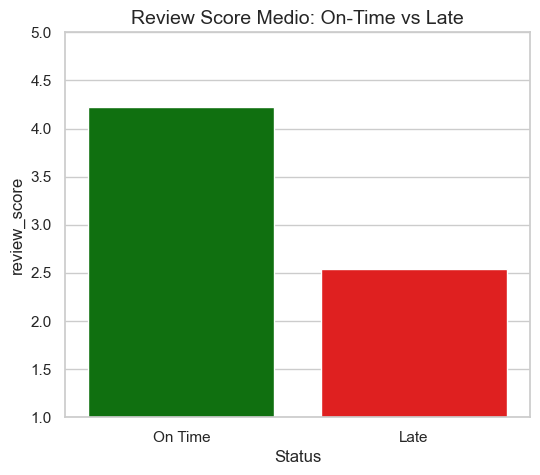

In [44]:
avg_score = df_merged.groupby('is_late')['review_score'].mean().reset_index()
avg_score['Status'] = avg_score['is_late'].map({False: 'On Time', True: 'Late'})

plt.figure(figsize=(6, 5))
sns.barplot(data=avg_score, x='Status', y='review_score', palette=['green', 'red'])
plt.title('Review Score Medio: On-Time vs Late', fontsize=14)
plt.ylim(1, 5)
plt.show()

ho provato il legame tra i tempi di attesa e le recensioni negative: più lunga è l'attesa, più basso è il punteggio

/var/folders/k7/9nwr8ll53yl1zxdfnc_v7n2w0000gn/T/ipykernel_5477/4051176436.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='review_score_rounded', y='delivery_days', data=df_merged, palette='coolwarm_r', showfliers=False)


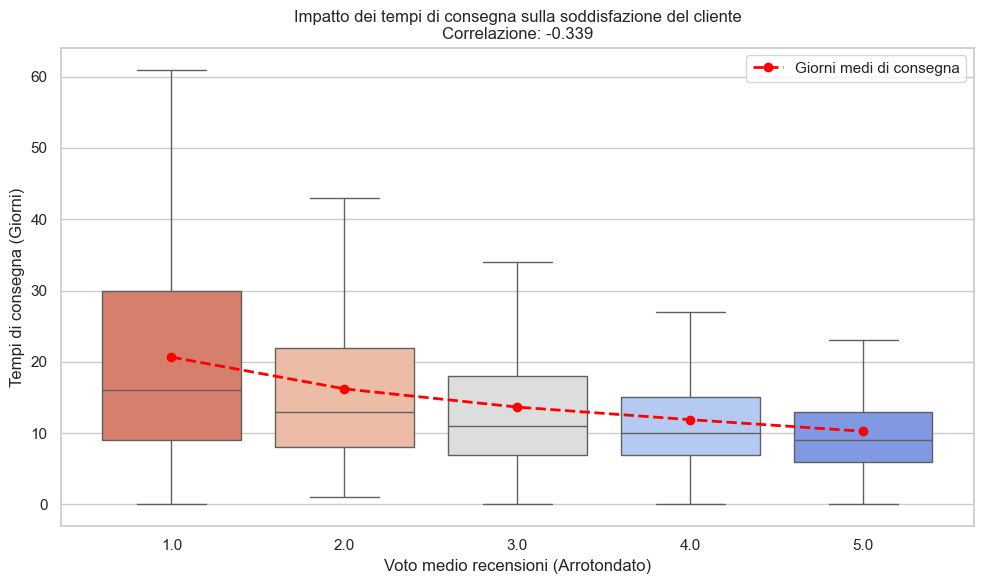

In [45]:
# voti arrotondati per creare gruppi più chiari sull'asse X (1, 2, 3, 4, 5)
corr = df_merged['delivery_days'].corr(df_merged['review_score'])
df_merged['review_score_rounded'] = df_merged['review_score'].round()

plt.figure(figsize=(10, 6))

sns.boxplot(x='review_score_rounded', y='delivery_days', data=df_merged, palette='coolwarm_r', showfliers=False)

# mostro la media dei giorni di consegna per ogni voto arrotondato 
mean_days = df_merged.groupby('review_score_rounded')['delivery_days'].mean()
plt.plot(range(len(mean_days)), mean_days.values, color='red', marker='o', linestyle='dashed', linewidth=2, label='Giorni medi di consegna')

plt.title(f'Impatto dei tempi di consegna sulla soddisfazione del cliente\nCorrelazione: {corr:.3f}')
plt.xlabel('Voto medio recensioni (Arrotondato)')
plt.ylabel('Tempi di consegna (Giorni)')
plt.legend()
plt.tight_layout()

l'analisi di questi due nuovi grafici  evidenziano che l'efficienza logistica è il vero ostacolo alla retention. Un disservizio logistico azzera di fatto il valore generato, compromettendo l'intera customer experience

Un ordine consegnato in ritardo dimezza letteralmente la soddisfazione del cliente. Il punteggio medio delle recensioni crolla da un eccellente ~4.2 (On Time) a un critico ~2.5 (Late). Questo livello di insoddisfazione brucia le possibilità di riacquisto.

Il box plot dimostra che  clienti pienamente soddisfatti (5 stelle) ricevono costantemente la merce in tempi brevi, con una media intorno ai 10 giorni e una varianza molto contenuta (il box è corto e compatto).

Guardando le recensioni a 1 stella, il problema non è solo che la media dei giorni di consegna sale a oltre 20, ma che la varianza esplode (il box si allunga verticalmente, con picchi fino a 60 giorni). Quindi l'imprevedibilità e la mancanza di comunicazione penalizzano il brand prima ancora che il cliente riceva il pacco.

In [46]:
df_filtered.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_year', 'month_year'],
      dtype='object')

/var/folders/k7/9nwr8ll53yl1zxdfnc_v7n2w0000gn/T/ipykernel_5477/1017771650.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geo['delivery_days'] = (df_geo['order_delivered_customer_date'] - df_geo['order_purchase_timestamp']).dt.days
/var/folders/k7/9nwr8ll53yl1zxdfnc_v7n2w0000gn/T/ipykernel_5477/1017771650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


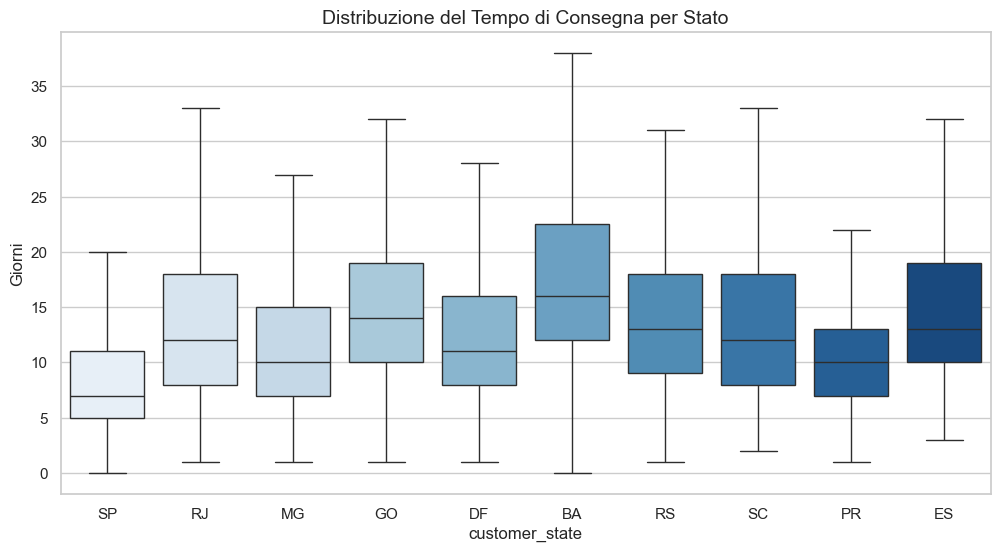

In [47]:
# Tempo di consegna per stato (Top 10 Stati)
top_states = df_filtered['customer_state'].value_counts().head(10).index
df_geo = df_filtered[df_filtered['customer_state'].isin(top_states)]

# 2. Re-create the 'delivery_days' column inside df_geo
df_geo['delivery_days'] = (df_geo['order_delivered_customer_date'] - df_geo['order_purchase_timestamp']).dt.days

# 3. Now your plot code will work perfectly
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_geo, 
    x='customer_state', 
    y='delivery_days', 
    showfliers=False, 
    palette='Blues'
)

plt.title('Distribuzione del Tempo di Consegna per Stato', fontsize=14)
plt.ylabel('Giorni')
plt.show()

Avendo stabilito che i ritardi e l'imprevedibilità delle consegne sono il fattore di rischio per la fidelizzazione, ho segmentato i tempi di spedizione a livello geografico. Questo mi permette di isolare esattamente dove l'azienda sta perdendo valore a causa dei colli di bottiglia logistici.

Stati come Bahia (BA), Rio de Janeiro (RJ) ed Espírito Santo (ES) presentano criticità evidenti. Non solo i tempi mediani si alzano pericolosamente (arrivando a circa 16 giorni per BA), ma l'ampiezza dei box e gli estremi di variazione mostrano un'imprevedibilità estrema, con frequenti picchi oltre i 30 giorni. Come dimostrato in precedenza, è proprio questa incertezza a generare la maggior parte delle recensioni a 1 stella.


# Conclusioni

Dall'incrocio delle metriche di vendita, pricing e performance logistiche, ho elaborato le seguenti direttive per massimizzare la retention e i incassi.

 1. Strategia su 'Relogios & Presentes'

Logistica:  Poiché i clienti si aspettano un servizio all'altezza del prezzo, si può trovare un miglior coriere che garantisca miglior ritardi. Assorbire un costo di spedizione leggermente superiore per garantire consegne tassative entro 10 giorni, si ripagherà blindando le recensioni a 5 stelle e aumentando il Lifetime Value del cliente.

2. 'Beleza & Saude' è il driver trainante della crescita organica aziendale.

Consiglio di mantenere rigorose scorte di magazzino come buffer di sicurezza. Essendo la nostra principale fonte di guadagno venduta a prezzo pieno, gli stock-out qui sono inaccettabili.

Poiché si tratta spesso di acquisti ricorrenti, l'obiettivo logistico principale è la prevedibilità. Il cliente deve sapere con esattezza quando riceverà il riassortimento.

Infrastruttura (Lungo Termine):  Se i volumi in forte crescita si concentreranno in stati ad alta latenza logistica come Rio de Janeiro (RJ), consiglio di valutare l'apertura di partnership con operatori logistici regionali ultra-veloci o l'utilizzo di micro-hub di smistamento locali.

3. 'Cama, Mesa, Banho' è la categoria di volume, caratterizzata da articoli ingombranti e bassi margini, ed è statisticamente la più esposta a problematiche logistiche. 

Un ritardo in questo segmento genera un volume enorme di recensioni a 1 stella. Risulta per me strategico analizzare le performance dei singoli corrieri esclusivamente su questa categoria, rinegoziando i livelli di servizio per evitare che i ritardi compromettano la visibilità e il ranking dei nostri best-seller.

4. 'Esporte & Lazer' e 'Informatica'

I dati suggeriscono un forte valore percepito per 'Esporte & Lazer'. Pianificherò degli A/B test per ulteriori e leggeri aumenti di prezzo in quest'area al fine di massimizzare i margini di profitto senza intaccare i volumi.

Per 'Informatica Acessorios' consiglio svuotare l'inventario a basso rendimento e puntare a immagazzinare solo accessori tech premium a margine più elevato.

5. Ottimizzazione della Customer Experience.
Indipendentemente dalla categoria, la gestione delle aspettative si è rivelata il fattore chiave per tutelare il brand:

Per i clienti residenti in zone ad alta varianza logistica, è necessario modificare i tempi di consegna stimati mostrati in fase di acquisto. È strategicamente superiore promettere una consegna in 20 giorni e arrivare in 15, piuttosto che prometterne 10 e arrivare in 15 .

Implementare un trigger automatico: se un ordine entra nella "zona di rischio ritardo" (oltre i 12 giorni), il sistema invierà un'email automatica di scuse con un sconto per il prossimo acquisto. L'obiettivo è disinnescare l'insoddisfazione e prevenire la recensione a 1 stella prima che il cliente decida di scriverla.





